# Beyond isolation: candidate second axes for 4mu, and why the channel uses a mass fit

**Where this sits in the series.** Notebooks 01-04 established that in the 4mu
channel no isolation-based ABCD plane works: the isolated signal region is
saturated, its sidebands are empty, and the corner is dominated by an
instrumental fake (characterized further in notebook 08). An ABCD needs a
*second* variable, independent of isolation, that still isolates signal. This
notebook asks whether such a variable exists in 4mu, tests the three
structural candidates on signal MC, and explains why the channel instead
adopts a **windowed dimuon-resonance mass fit**.

**The obstruction, stated up front.** A 4mu event offers only two *families*
of observables:

* **event-kinematic** — isolation, di-lepton-jet mass m_JJ, opening angles.
  These all respond to one latent variable, the hadronic activity of the
  event.
* **muon-reconstruction** — displacement, DSA-vs-PF content, vertex quality,
  charge, and dimuon-mass resolution. These all respond to how the muons were
  reconstructed.

An ABCD needs two axes with *no shared latent variable*. Any two axes drawn
from the same family share one, so the plane does not factorize. The 2mu2e
channel escapes because its electron/photon leg is a genuinely third,
independent family (the basis for its egmiso x mudisp plane); a muon-only
final state has no third family. Everything below is a concrete test of that
argument.

**What is MC and what is deferred.** Signal discrimination is an MC question
and is answered here in full. Whether a candidate is independent *of isolation
for background* is a statement about background events in the isolated corner,
which is an instrumental population that Monte Carlo does not reproduce (see
notebook 08) -- so the empirical independence test belongs to the data
sidebands and is left to that continuation. This notebook establishes the
signal behavior and the structural argument; it does not use collision data.

In [1]:
import glob, re
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
import coffea.util as cu

plt.style.use(hep.style.CMS)

# MC-ONLY input: the signal 4Mu grid + background MC from the pair-resonance
# processing, staged to an MC-only directory. Regenerate from EOS:
#   root://cmseos.fnal.gov//store/group/lpcmetx/SIDM/coffea_outputs/murtazas/abcd_plane_study_pairres
# (that directory contains NO collision data). The guard below refuses any
# DoubleMuon/data file so the notebook cannot read data even by mistake.
MCDIR = "/uscms_data/d3/murtazas/abcd_plane_study_pairres_local"

def _mc_files(pattern):
    fs = sorted(glob.glob(MCDIR + "/" + pattern))
    for f in fs:
        assert "DoubleMuon" not in f and "/Data/" not in f, "refusing data file: " + f
    return fs

def load(pattern, hname):
    out = None
    for f in _mc_files(pattern):
        o = cu.load(f); o = o.get("out", o)
        for ds in o.values():
            h = ds["hists"][hname]
            out = h.copy() if out is None else out + h
    return out

def arr(hist_obj, ch):
    hch = hist_obj[{"channel": ch}]
    names = [a.name for a in hch.axes]
    v = hch.view(); v = v["value"] if v.dtype.names else v
    i = names.index("parity"); v = v.sum(axis=i); names.pop(i)
    return v, names

def red(v, names, keep, sel=None):
    sl = [slice(None)] * v.ndim
    for k, s in (sel or {}).items():
        sl[names.index(k)] = s
    vv = v[tuple(sl)]
    return vv.sum(axis=tuple(i for i, n in enumerate(names) if n not in keep))

def ptok(t): return float(t.replace("p", "."))
def parse(name):
    m = re.match(r"4Mu_(\d+)GeV_([0-9p]+)GeV_([0-9p]+)mm", name)
    return int(m.group(1)), ptok(m.group(2)), ptok(m.group(3))

SIG4 = [f.split("/")[-1].replace(".coffea", "") for f in _mc_files("4Mu_*.coffea")]
print("MC-only load. signal 4Mu points:", len(SIG4), "| data files seen: 0 (guarded)")

MC-only load. signal 4Mu points: 13 | data files seen: 0 (guarded)


## 1. The three candidate axes

Each candidate lives in structure a *combinatoric* background lacks but a real
dark-photon pair has, and each should therefore enrich signal:

* **Mass equality**, `dmrel = |m0 - m1| / (m0 + m1)` of the two muon
  lepton-jet dimuon masses. Two decays of the *same* dark photon give equal
  masses at any mass point -- no mass scan needed; a combinatoric pairing of
  unrelated muons is broad.
* **Charge pairing**, `qbal` = how many of the two leading mu-LJs are
  exactly-two-muon *same-sign* pairs. A dark-photon decay is strictly
  opposite-sign; same-sign lepton-jets tag combinatoric/fake background
  through a quantum number no isolation or displacement cut touches.
* **Vertex DCA**, the 3D distance of closest approach of the best within-LJ
  Kalman dimuon vertex. Two muons from one decay point intersect (small DCA);
  a fake pairing does not.

All three are read from the pair-resonance processing histograms
(`abcd_dmrel_4mu`, `abcd_qbal_4mu`, `abcd_vdca_4mu`). We first confirm each
actually separates signal.

In [2]:
PASS = {"abcd_dmrel_4mu": ("dmrel", slice(0, 3), "dmrel < 0.2"),
        "abcd_qbal_4mu":  ("qbal", slice(0, 1), "no same-sign LJ (qbal=0)"),
        "abcd_vdca_4mu":  ("vdca", slice(1, 5), "vertex DCA < 0.05 cm")}

SIG = {}
for name in SIG4:
    row = {}
    for hname, (ax, apass, desc) in PASS.items():
        v, names = arr(load(name + ".coffea", hname), "4mu_abcd_scan")
        tot = red(v, names, keep=[ax]).sum()
        row[ax] = float(red(v, names, keep=[ax])[apass].sum() / tot) if tot else np.nan
    # dmrel shape split by pixel content (PF-quality vs DSA-side)
    v, names = arr(load(name + ".coffea", "abcd_dmrel_4mu"), "4mu_abcd_scan")
    for lab, sl in (("pf", slice(1, 2)), ("dsa", slice(0, 1))):
        e = red(v, names, keep=["dmrel"], sel={"pix0": sl})
        row["dmrel_" + lab] = float(e[0:3].sum() / e.sum()) if e.sum() else np.nan
    SIG[name] = row
    mb, mdp, ct = parse(name)
    print("%-30s dmrel<0.2 %.2f (PF %.2f/DSA %.2f)  qbal=0 %.2f  vdca<0.05 %.2f"
          % (name, row["dmrel"], row["dmrel_pf"], row["dmrel_dsa"], row["qbal"], row["vdca"]))

4Mu_1000GeV_1p2GeV_0p0096mm    dmrel<0.2 0.87 (PF 0.88/DSA 0.78)  qbal=0 0.98  vdca<0.05 0.92
4Mu_1000GeV_1p2GeV_0p96mm      dmrel<0.2 0.38 (PF 0.52/DSA 0.32)  qbal=0 0.89  vdca<0.05 0.55


4Mu_1000GeV_1p2GeV_9p6mm       dmrel<0.2 0.25 (PF 0.26/DSA 0.25)  qbal=0 0.81  vdca<0.05 0.35
4Mu_100GeV_1p2GeV_0p096mm      dmrel<0.2 0.98 (PF 0.98/DSA 0.94)  qbal=0 1.00  vdca<0.05 0.98


4Mu_100GeV_1p2GeV_96p0mm       dmrel<0.2 0.32 (PF 0.30/DSA 0.32)  qbal=0 0.91  vdca<0.05 0.22
4Mu_100GeV_1p2GeV_9p6mm        dmrel<0.2 0.48 (PF 0.67/DSA 0.44)  qbal=0 0.96  vdca<0.05 0.53


4Mu_500GeV_0p25GeV_0p4mm       dmrel<0.2 0.24 (PF 0.30/DSA 0.22)  qbal=0 0.92  vdca<0.05 0.39
4Mu_500GeV_0p25GeV_4p0mm       dmrel<0.2 0.21 (PF 0.12/DSA 0.22)  qbal=0 0.88  vdca<0.05 0.24


4Mu_500GeV_1p2GeV_0p019mm      dmrel<0.2 0.93 (PF 0.94/DSA 0.85)  qbal=0 1.00  vdca<0.05 0.95
4Mu_500GeV_1p2GeV_19p0mm       dmrel<0.2 0.26 (PF 0.28/DSA 0.26)  qbal=0 0.89  vdca<0.05 0.29


4Mu_500GeV_1p2GeV_1p9mm        dmrel<0.2 0.41 (PF 0.57/DSA 0.36)  qbal=0 0.94  vdca<0.05 0.53
4Mu_500GeV_5p0GeV_80p0mm       dmrel<0.2 0.44 (PF 0.59/DSA 0.43)  qbal=0 0.89  vdca<0.05 0.33


4Mu_500GeV_5p0GeV_8p0mm        dmrel<0.2 0.73 (PF 0.84/DSA 0.69)  qbal=0 0.96  vdca<0.05 0.62


The three axes do enrich signal, but each with a lifetime and mass
dependence that decides where it can be used. The figure below plots the
signal efficiency of each pass requirement versus proper lifetime, one curve
per (m_Bs, m_Zd) point.

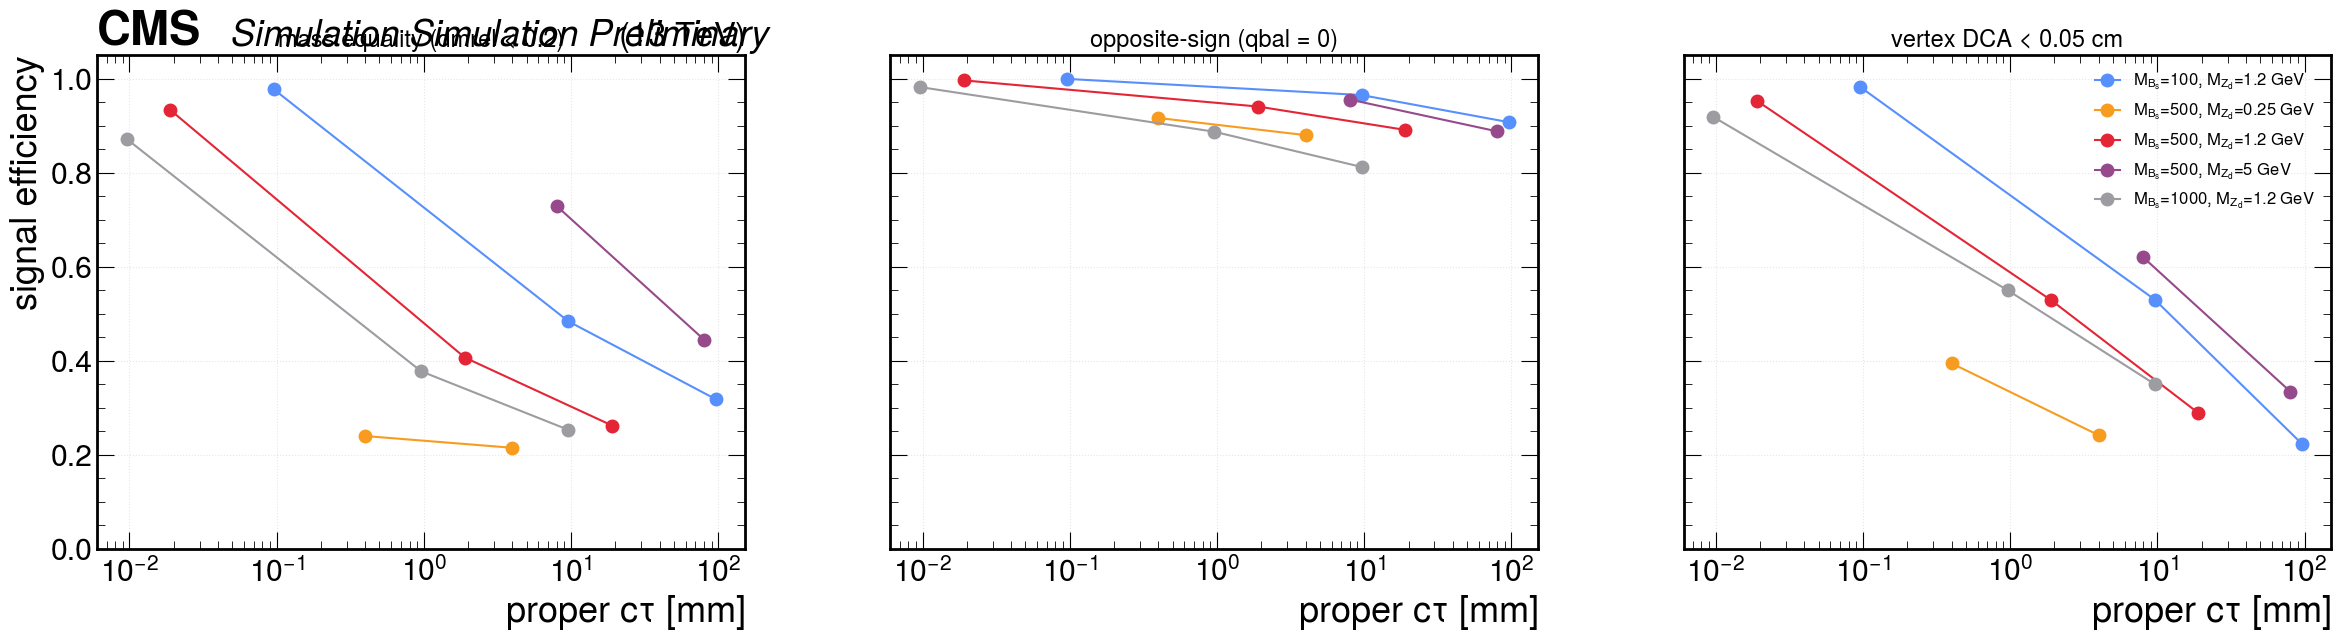

In [3]:
fig, axs = plt.subplots(1, 3, figsize=(24, 7), sharey=True)
series = {}
for name, row in SIG.items():
    mb, mdp, ct = parse(name)
    series.setdefault((mb, mdp), []).append((ct, row))
for (mb, mdp), pts in sorted(series.items()):
    pts.sort()
    cts = [p[0] for p in pts]
    for ax, key in zip(axs, ("dmrel", "qbal", "vdca")):
        ax.plot(cts, [p[1][key] for p in pts], "o-", ms=9,
                label=r"$M_{B_s}$=%d, $M_{Z_d}$=%.2g GeV" % (mb, mdp))
for ax, ttl in zip(axs, ("mass equality (dmrel < 0.2)", "opposite-sign (qbal = 0)",
                         "vertex DCA < 0.05 cm")):
    ax.set_xscale("log"); ax.set_xlabel(r"proper $c\tau$ [mm]")
    ax.set_title(ttl, fontsize=17); ax.set_ylim(0, 1.05); ax.grid(alpha=0.3)
axs[0].set_ylabel("signal efficiency"); axs[2].legend(fontsize=12)
hep.cms.label("Simulation Preliminary", data=False, ax=axs[0])
plt.tight_layout(); plt.show()

**Reading the signal behavior.**

* **Mass equality** is governed by dimuon-mass resolution, which degrades two
  ways. With *lifetime*: at the nominal 1.2 GeV dark photon the efficiency
  falls from ~0.9-1.0 prompt to ~0.2-0.5 displaced, because displaced decays
  are reconstructed with muon-system-only (DSA) muons whose momentum
  resolution smears the mass. With *mass*: a light 0.25 GeV dark photon is
  collimated and low-mass, so its efficiency is only ~0.24 even prompt, while
  a heavy 5 GeV point stays ~0.6-0.7 even at 8 mm. Mass equality is a
  discriminant for *heavy dark photons at short lifetime* -- the opposite
  corner from where a displaced search needs it.
* **Opposite-sign** is nearly lifetime-flat (0.81-1.00): charge
  mis-assignment costs a few percent, worst for the softest, most displaced
  muons.
* **Vertex DCA** falls steeply with lifetime (0.9+ prompt to ~0.2-0.35
  displaced): muon-system-only DCA resolution degrades with displacement, so
  a tight DCA cut trades away exactly the displaced signal the search targets.
  It is a diagnostic, not a selection (contrast the vertex chi2 requirement of
  notebook 08, whose efficiency declines far more gently).

## 2. Why none of them rescues the ABCD

Signal discrimination is necessary but not sufficient. For an ABCD the axis
must also be *independent of isolation for background*. Two points settle it:

1. **The structural argument.** Every candidate lives in the
   muon-reconstruction family: mass equality is set by DSA momentum
   resolution, charge by DSA charge assignment, DCA by the muon-system vertex
   fit. Isolation-adjacent background structure (the DSA-fake content of the
   isolated corner) drives all of them, so each is correlated with the
   isolation axis by construction. There is no third family to draw an
   independent axis from -- the obstruction stated in the header.
2. **The empirical test is a data measurement.** The isolated-corner
   background is an instrumental population (notebook 08) that MC does not
   reproduce, so the factorization of any candidate against isolation can only
   be measured on the data sidebands. That test -- the continuation of this
   study on data -- is where the candidates are confirmed to fail; it is not
   an MC result and is not shown here.

The practical consequence: 4mu gets no second ABCD axis. What it *does* have
is the one structural feature every candidate was chasing -- the two muon
lepton-jets are decays of the same resonance -- which points to a different
method entirely.

## 3. The 2mu2e contrast: a genuinely independent second axis

The two-family argument makes a testable prediction: the 2mu2e channel, which
*does* have a third observable family (electron/photon isolation), should
support an ABCD where 4mu cannot. The plane that realizes this pairs egm-LJ
isolation with muon displacement -- two variables from disjoint families (EGM
reconstruction vs muon reconstruction), so the hadronic-activity latent
variable that drives isolation projects onto at most one axis. On 2mu2e
background MC the two variables factorize, confirming the prediction; the same
construction on any 4mu axis pair does not.

A caveat stated plainly: the histograms here are filled *unweighted*, so the
counts below are raw MC statistics (dominated by high-pT QCD), and the
A·D/(B·C) is a **variable-independence check, not a physically-weighted
closure** -- weighted 2mu2e MC is n_eff-limited (notebook 02). The
physically-weighted closure, with real sideband statistics, is a data-sideband
measurement and is the continuation of this study. What MC establishes here is
the structural point that distinguishes the two channels.

In [4]:
def load_bkg(hname):
    out = None
    for f in _mc_files("*.coffea"):
        b = f.split("/")[-1]
        if b.startswith(("4Mu_", "2Mu2E_")) or b == "signal_costag.coffea":
            continue
        o = cu.load(f); o = o.get("out", o)
        for ds in o.values():
            h = ds["hists"][hname]
            out = h.copy() if out is None else out + h
    return out

vb, nb2 = arr(load_bkg("abcd_dmrel_2mu2e"), "2mu2e_abcd_scan")
# egmisoc x mudisp plane at mJJ >= 150; iso/pix bins 0:2 = pass, bin 2 = fail
mjjf = load_bkg("abcd_dmrel_2mu2e")[{"channel": "2mu2e_abcd_scan"}].axes["mjjf"]
ctr = 0.5 * (np.asarray(mjjf.edges)[:-1] + np.asarray(mjjf.edges)[1:]); ctr[-1] = 1005.
plane = red(vb, nb2, keep=["egmisoc", "mudisp", "mjjf"])
kn = [n for n in nb2 if n in ("egmisoc", "mudisp", "mjjf")]
plane = np.transpose(plane, [kn.index("egmisoc"), kn.index("mudisp"), kn.index("mjjf")])
hi = ctr >= 150.
A = plane[0:2, 0:2, hi].sum(); B = plane[2, 0:2, hi].sum()
Cc = plane[0:2, 2, hi].sum(); Dd = plane[2, 2, hi].sum()
kappa = A * Dd / (B * Cc)
print("2mu2e egmiso x mudisp, mJJ >= 150 (unweighted background MC):")
print("  A(pass,pass)=%.0f  B(egm-fail)=%.0f  C(mudisp-fail)=%.0f  D(both fail)=%.0f"
      % (A, B, Cc, Dd))
print("  A_pred = B*C/D = %.0f   ->  A_obs/A_pred = kappa = %.3f  (1 = variables factorize)"
      % (B * Cc / Dd, kappa))
print("  [unweighted variable-independence check; physical closure is a data measurement]")

2mu2e egmiso x mudisp, mJJ >= 150 (unweighted background MC):
  A(pass,pass)=390  B(egm-fail)=1059  C(mudisp-fail)=913  D(both fail)=2363
  A_pred = B*C/D = 409   ->  A_obs/A_pred = kappa = 0.953  (1 = variables factorize)
  [unweighted variable-independence check; physical closure is a data measurement]


The egm-isolation and muon-displacement axes factorize (κ close to 1), the
condition an ABCD needs, while every 4mu candidate above does not -- the
difference being entirely that 2mu2e has an independent third family and 4mu
does not. With the 2mu2e ABCD established on its own footing (its physical
closure measured on data), the remaining question is what 4mu does instead.

## 4. The 4mu resolution: a windowed dimuon-resonance mass fit

The signal is a narrow peak in m_JJ (the two-lepton-jet mass ~ the parent
mass); the background is smooth. Rather than predict a blinded corner from an
ABCD identity, the 4mu estimate becomes a **bump hunt**: blind a mass window
around each signal hypothesis, fit the smooth background from the visible
sidebands on either side, and integrate under the window. This trades the
ABCD factorization assumption -- which 4mu cannot satisfy -- for a
*smoothness* assumption on the mass spectrum, which is weaker and testable in
the open sidebands.

The windows are set by the signal's own mass resolution. The figure shows the
signal m_JJ line shape for the simulated points and its 68% core; those cores
motivate the pre-registered blind windows. The background spectrum and the
fit itself are measured on data (the continuation), so only the signal shape
appears here.

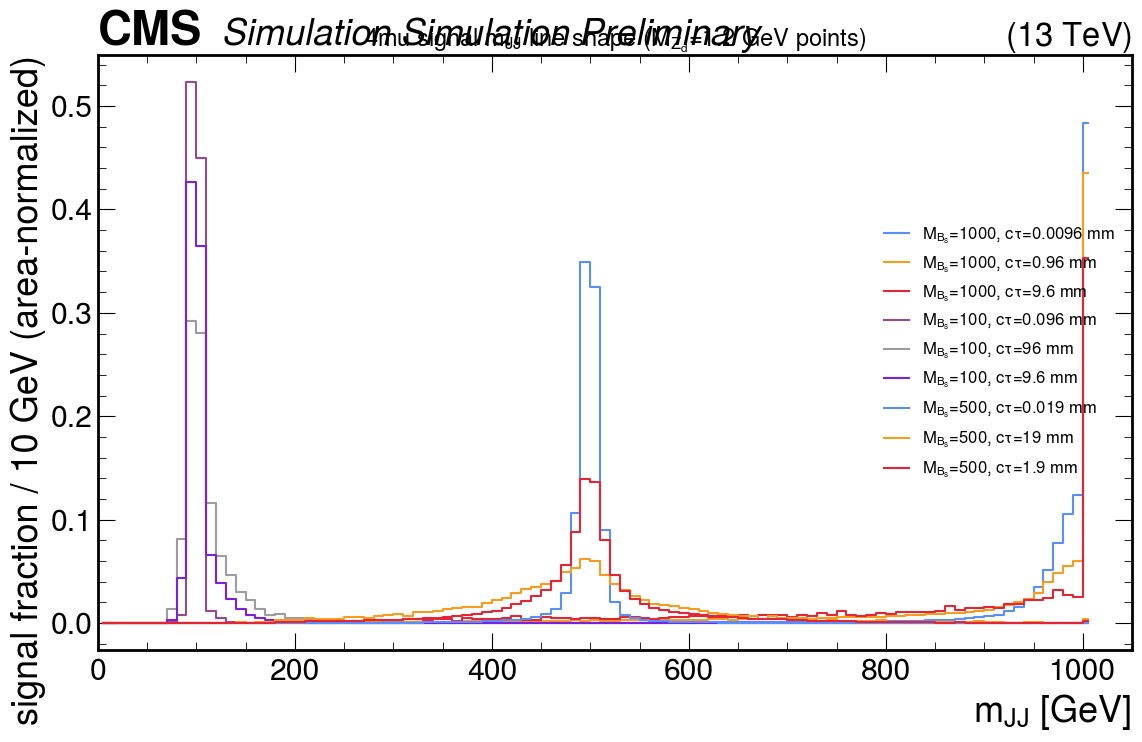

68% m_JJ cores (GeV):
  M_Bs= 100 ctau=  0.096 mm : [95, 95]
  M_Bs= 100 ctau=  9.600 mm : [95, 95]
  M_Bs= 100 ctau= 96.000 mm : [95, 105]
  M_Bs= 500 ctau=  0.019 mm : [495, 505]
  M_Bs= 500 ctau=  1.900 mm : [445, 535]
  M_Bs= 500 ctau= 19.000 mm : [395, 575]
  M_Bs=1000 ctau=  0.010 mm : [995, 1005]
  M_Bs=1000 ctau=  0.960 mm : [955, 1005]
  M_Bs=1000 ctau=  9.600 mm : [755, 1005]


In [5]:
fig, ax = plt.subplots(figsize=(12, 8))
cores = []
for name in SIG4:
    mb, mdp, ct = parse(name)
    if abs(mdp - 1.2) > 1e-6:
        continue
    v, names = arr(load(name + ".coffea", "abcd_dmrel_4mu"), "4mu_abcd_scan")
    mjj = red(v, names, keep=["mjjf"])
    hch = load(name + ".coffea", "abcd_dmrel_4mu")[{"channel": "4mu_abcd_scan"}]
    edg = np.asarray(hch.axes["mjjf"].edges); ctr = 0.5 * (edg[:-1] + edg[1:]); ctr[-1] = 1005.
    tot = mjj.sum()
    if tot == 0:
        continue
    # 68% core about the mode
    order = np.argsort(-mjj); cum = np.cumsum(mjj[order]) / tot
    core = np.sort(ctr[order[cum <= 0.68]])
    if len(core):
        cores.append((mb, ct, core.min(), core.max()))
    ax.step(ctr, mjj / tot, where="mid", label=r"$M_{B_s}$=%d, $c\tau$=%.3g mm" % (mb, ct))
ax.set_xlim(0, 1050); ax.set_xlabel(r"$m_{JJ}$ [GeV]")
ax.set_ylabel("signal fraction / 10 GeV (area-normalized)")
ax.set_title(r"4mu signal $m_{JJ}$ line shape ($M_{Z_d}$=1.2 GeV points)", fontsize=17)
ax.legend(fontsize=12); hep.cms.label("Simulation Preliminary", data=False, ax=ax)
plt.tight_layout(); plt.show()
print("68% m_JJ cores (GeV):")
for mb, ct, lo, hi in sorted(cores):
    print("  M_Bs=%4d ctau=%7.3f mm : [%.0f, %.0f]" % (mb, ct, lo, hi))

## Takeaways for the continuation

* **4mu has no second axis independent of isolation.** The three structural
  candidates -- mass equality, opposite-sign charge, vertex DCA -- all live in
  the muon-reconstruction family, so each is correlated with isolation; there
  is no third family (the 2mu2e escape route) in a muon-only final state. The
  empirical independence test against isolation is a *data-sideband*
  measurement and is the natural next step for whoever continues this study.
* **The candidates still enrich signal**, with a mass/lifetime pattern worth
  keeping: mass equality is a heavy-dark-photon, short-lifetime discriminant;
  opposite-sign is nearly lifetime-flat; vertex DCA is displacement-sensitive
  and diagnostic only.
* **The 4mu background method is a windowed mass fit**, not an ABCD: blind a
  window at each mass hypothesis, fit the smooth sidebands, integrate. The
  window widths follow the signal m_JJ cores shown here. Building and
  validating that fit on data -- and re-testing the same-sign tag as a
  possible background-cleaning veto -- is the data-side continuation.